# Experiment: Mediano Discrete Benchmark

这个 notebook 只保留实验一需要的两个核心输出：

- 一张带小写 `a-f` 子图编号的六联八节点示意总图；
- 一张双面板柱状图，同时汇总总 `EI` 与 `\Phi^{\mathrm{EID}}`。

新的 `E` 被改成“社区内更密、社区间仅有两条弱桥接边”的控制例子，用来说明局部高密度并不自动等于高整体协同。 


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    exp_candidate = candidate / "exp"
    if exp_candidate.exists():
        exp_candidate_str = str(exp_candidate)
        if exp_candidate_str not in sys.path:
            sys.path.insert(0, exp_candidate_str)
    if (candidate / "utils.py").exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

from discrete_benchmark_helpers import (
    BENCHMARK_NETWORKS,
    compute_benchmark_results,
    export_benchmark_artifacts,
    render_benchmark_topology_overview_svg,
    render_benchmark_ei_phi_summary_svg,
    render_metric_bar_chart_svg,
)

try:
    from IPython.display import SVG, display
except Exception:  # pragma: no cover - notebook fallback
    SVG = None
    display = print


## Six-network overview

下图把六个网络并排成一张完整总图，并统一用小写 `a-f` 标记子图编号。`e` 对应新的密社区弱桥接控制：两个 4 节点社区内部更密，但跨社区只有两条弱桥接边。 


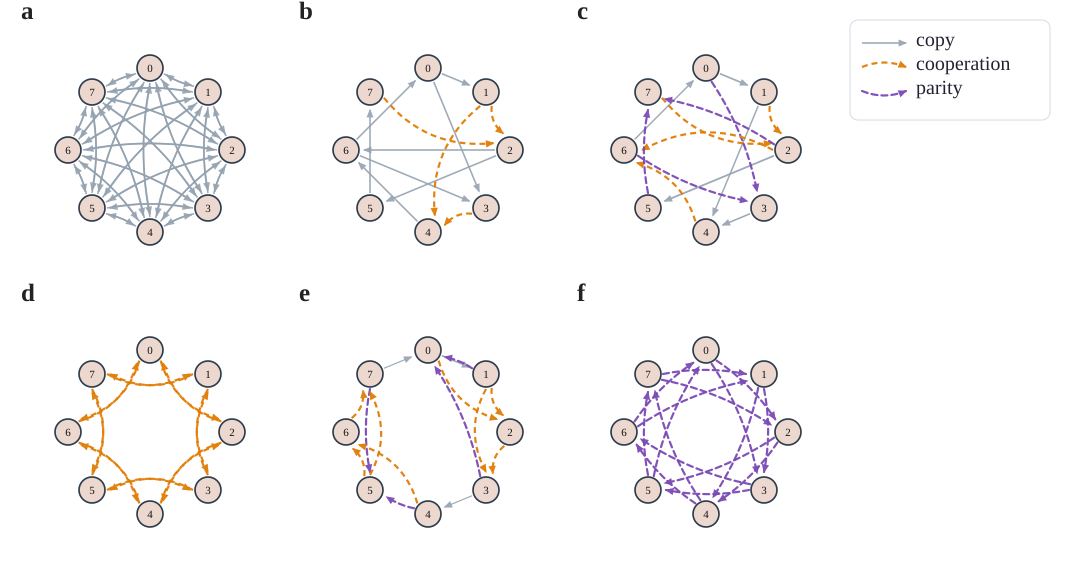

In [2]:
topology_layout_style = {
    "panel_width": 260,
    "panel_height": 260,
    "horizontal_gap": 18,
    "vertical_gap": 22,
    "outer_margin_x": 20,
    "outer_margin_y": 20,
}

topology_legend_style = {
    "show": True,
    "x": 850,
    "y": 20,
    "width": 200,
    "height": 100,
    "title": None,
    "title_font_size": 23,
    "item_font_size": 20,
    "item_spacing": 24,
}

topology_connection_style = {
    "copy": {
        "stroke": "#93a1af",
        "stroke_width_base": 1.05,
        "stroke_width_scale": 0.55,
        "start_offset": 15.0,
        "end_offset": 18.0,
        "bidirectional_curvature": 0.10,
        "marker_width": 8.6,
        "marker_height": 7.0,
        "marker_ref_x": 7.4,
        "marker_ref_y": 3.5,
        "marker_fill": "#93a1af",
    },
    "cooperation": {
        "stroke": "#e17c05",
        "stroke_width": 2.2,
        "dash": "6,4",
        "start_offset": 15.0,
        "end_offset": 18.0,
        "curvature": 0.27,
        "marker_width": 8.6,
        "marker_height": 7.4,
        "marker_ref_x": 7.5,
        "marker_ref_y": 3.7,
        "marker_fill": "#e17c05",
    },
    "parity": {
        "stroke": "#7b4ab5",
        "stroke_width": 2.2,
        "dash": "6,4",
        "start_offset": 15.0,
        "end_offset": 18.0,
        "curvature": 0.1,
        "marker_width": 8.6,
        "marker_height": 7.4,
        "marker_ref_x": 7.5,
        "marker_ref_y": 3.7,
        "marker_fill": "#7b4ab5",
    },
}

topology_connection_filter_style = {
    "drop_shared_parity_sources": True,
}

topology_label_style = {
    "show": True,
    "dx": 1,
    "dy": -1,
    "font_size": 25,
    "fill": "#222",
    "font_weight": "700",
}

topology_overview_svg = render_benchmark_topology_overview_svg(
    BENCHMARK_NETWORKS,
    panel_width=topology_layout_style["panel_width"],
    panel_height=topology_layout_style["panel_height"],
    horizontal_gap=topology_layout_style["horizontal_gap"],
    vertical_gap=topology_layout_style["vertical_gap"],
    outer_margin_x=topology_layout_style["outer_margin_x"],
    outer_margin_y=topology_layout_style["outer_margin_y"],
    show_mechanism_legend=topology_legend_style["show"],
    mechanism_legend_x=topology_legend_style["x"],
    mechanism_legend_y=topology_legend_style["y"],
    mechanism_legend_width=topology_legend_style["width"],
    mechanism_legend_height=topology_legend_style["height"],
    mechanism_legend_title=topology_legend_style["title"],
    mechanism_legend_title_font_size=topology_legend_style["title_font_size"],
    mechanism_legend_item_font_size=topology_legend_style["item_font_size"],
    mechanism_legend_item_spacing=topology_legend_style["item_spacing"],
    connection_style=topology_connection_style,
    connection_filter_style=topology_connection_filter_style,
    show_panel_letters=topology_label_style["show"],
    panel_letter_dx=topology_label_style["dx"],
    panel_letter_dy=topology_label_style["dy"],
    panel_letter_font_size=topology_label_style["font_size"],
    panel_letter_fill=topology_label_style["fill"],
    panel_letter_font_weight=topology_label_style["font_weight"],
)
if SVG is not None:
    display(SVG(topology_overview_svg))
else:
    print(topology_overview_svg)


## Total EI and $\Phi^{\mathrm{EID}}$

下面两张柱状图只保留实验一正文真正要引用的两个系统级量：总 `EI` 与 `\Phi^{\mathrm{EID}}`，横轴标签也统一使用小写 `a-f`。 


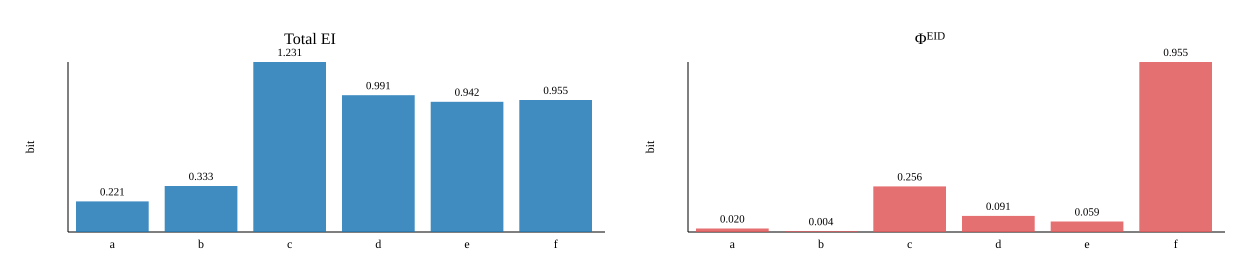

In [3]:
benchmark_results = compute_benchmark_results(BENCHMARK_NETWORKS)
ei_bar_chart_svg = render_metric_bar_chart_svg("ei", "Total EI", benchmark_results, color="#1F77B4")
phi_bar_chart_svg = render_metric_bar_chart_svg("phi_eid", r'$\Phi^{\mathrm{EID}}$', benchmark_results, color="#E15759")
ei_phi_summary_svg = render_benchmark_ei_phi_summary_svg(benchmark_results)
if SVG is not None:
    display(SVG(ei_phi_summary_svg))
else:
    print(ei_phi_summary_svg)


In [4]:
repo_root = next(candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (candidate / "utils.py").exists())
artifact_dir = repo_root / "fig" / "mediano_discrete_benchmark"
export_benchmark_artifacts(
    artifact_dir,
    BENCHMARK_NETWORKS,
    benchmark_results,
    topology_overview_kwargs={
        "panel_width": topology_layout_style["panel_width"],
        "panel_height": topology_layout_style["panel_height"],
        "horizontal_gap": topology_layout_style["horizontal_gap"],
        "vertical_gap": topology_layout_style["vertical_gap"],
        "outer_margin_x": topology_layout_style["outer_margin_x"],
        "outer_margin_y": topology_layout_style["outer_margin_y"],
        "show_mechanism_legend": topology_legend_style["show"],
        "mechanism_legend_x": topology_legend_style["x"],
        "mechanism_legend_y": topology_legend_style["y"],
        "mechanism_legend_width": topology_legend_style["width"],
        "mechanism_legend_height": topology_legend_style["height"],
        "mechanism_legend_title": topology_legend_style["title"],
        "mechanism_legend_title_font_size": topology_legend_style["title_font_size"],
        "mechanism_legend_item_font_size": topology_legend_style["item_font_size"],
        "mechanism_legend_item_spacing": topology_legend_style["item_spacing"],
        "connection_style": topology_connection_style,
        "connection_filter_style": topology_connection_filter_style,
        "show_panel_letters": topology_label_style["show"],
        "panel_letter_dx": topology_label_style["dx"],
        "panel_letter_dy": topology_label_style["dy"],
        "panel_letter_font_size": topology_label_style["font_size"],
        "panel_letter_fill": topology_label_style["fill"],
        "panel_letter_font_weight": topology_label_style["font_weight"],
    },
)
artifact_dir


PosixPath('fig/mediano_discrete_benchmark')

## Publication-style redraw

这节追加一组不覆盖旧结果的论文风格重绘图，所有新文件写入 `fig/mediano_discrete_benchmark_publication/`。

**Figure contract.** Claim: across the six discrete benchmark mechanisms, the highest-order synergy component changes more selectively than total EI, with the parity-only cycle concentrating its effective information in `Phi^EID`. Evidence: a clean topology overview links labels `a-f` to mechanism classes; the paired quantitative panels keep `EI` and `Phi^EID` on separate axes so the two scales are not visually conflated. Export: SVG is the editable primary format, with PDF/PNG previews and CSV source data for the quantitative panel.


In [1]:
from __future__ import annotations

import csv
import json
import os
import sys
from pathlib import Path

import numpy as np

repo_root = next(
    candidate
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "utils.py").exists()
)
os.environ.setdefault("MPLCONFIGDIR", str(repo_root / "exp" / "tmp" / "matplotlib"))

import matplotlib as mpl
import matplotlib.pyplot as plt

exp_path = repo_root / "exp"
if str(exp_path) not in sys.path:
    sys.path.insert(0, str(exp_path))

from discrete_benchmark_helpers import (
    BENCHMARK_NETWORKS,
    PANEL_LOWERCASE,
    PANEL_ORDER,
    compute_benchmark_results,
    render_benchmark_topology_overview_svg,
)

try:
    from IPython.display import SVG, display
except Exception:  # pragma: no cover - notebook fallback
    SVG = None
    display = print

publication_dir = repo_root / "fig" / "mediano_discrete_benchmark_publication"
publication_dir.mkdir(parents=True, exist_ok=True)

benchmark_results_publication = compute_benchmark_results(BENCHMARK_NETWORKS)
publication_rows = []
for network_key in PANEL_ORDER:
    result = benchmark_results_publication[network_key]
    total_ei = float(result["ei"])
    phi_eid = float(result["phi_eid"])
    publication_rows.append(
        {
            "network_key": network_key,
            "panel": PANEL_LOWERCASE[network_key],
            "label": str(result["label"]),
            "total_ei": total_ei,
            "phi_eid": phi_eid,
            "phi_fraction": phi_eid / total_ei if total_ei else np.nan,
        }
    )

source_data_path = publication_dir / "source_data_discrete_benchmark_publication.csv"
with source_data_path.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(publication_rows[0]))
    writer.writeheader()
    writer.writerows(publication_rows)

source_data_path.relative_to(repo_root)


PosixPath('fig/mediano_discrete_benchmark_publication/source_data_discrete_benchmark_publication.csv')

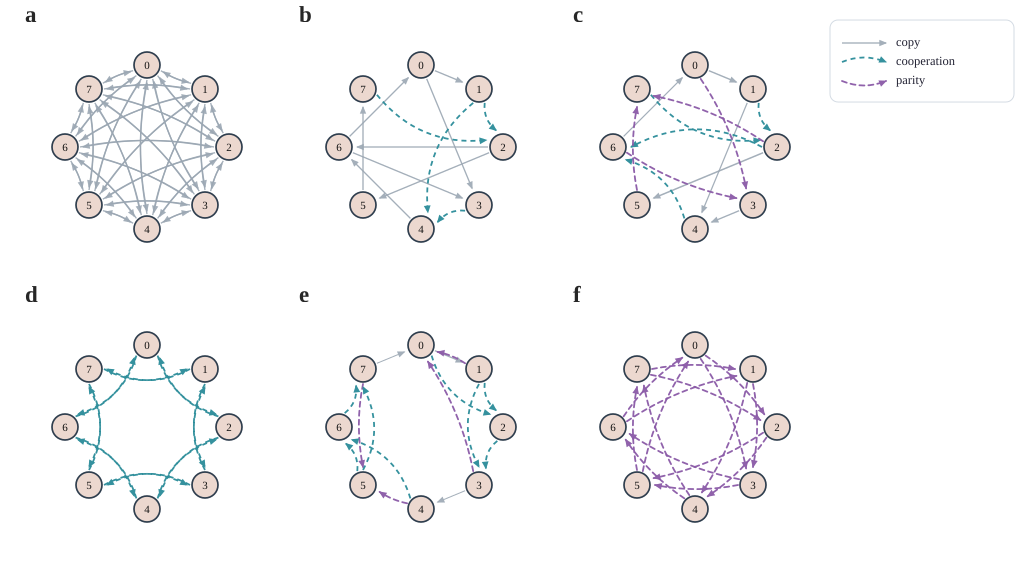

PosixPath('fig/mediano_discrete_benchmark_publication/six_network_mechanism_overview_nature.svg')

In [2]:
publication_connection_style = {
    "copy": {
        "stroke": "#9AA6B2",
        "stroke_width_base": 0.9,
        "stroke_width_scale": 0.45,
        "start_offset": 15.0,
        "end_offset": 18.0,
        "bidirectional_curvature": 0.10,
        "marker_width": 7.8,
        "marker_height": 6.4,
        "marker_ref_x": 6.7,
        "marker_ref_y": 3.2,
        "marker_fill": "#9AA6B2",
    },
    "cooperation": {
        "stroke": "#2B8C99",
        "stroke_width": 1.8,
        "dash": "5,4",
        "start_offset": 15.0,
        "end_offset": 18.0,
        "curvature": 0.27,
        "marker_width": 7.8,
        "marker_height": 6.8,
        "marker_ref_x": 6.8,
        "marker_ref_y": 3.4,
        "marker_fill": "#2B8C99",
    },
    "parity": {
        "stroke": "#8A5AA7",
        "stroke_width": 1.8,
        "dash": "5,4",
        "start_offset": 15.0,
        "end_offset": 18.0,
        "curvature": 0.10,
        "marker_width": 7.8,
        "marker_height": 6.8,
        "marker_ref_x": 6.8,
        "marker_ref_y": 3.4,
        "marker_fill": "#8A5AA7",
    },
}

publication_topology_svg = render_benchmark_topology_overview_svg(
    BENCHMARK_NETWORKS,
    panel_width=250,
    panel_height=250,
    horizontal_gap=24,
    vertical_gap=30,
    outer_margin_x=22,
    outer_margin_y=22,
    show_mechanism_legend=True,
    mechanism_legend_x=830,
    mechanism_legend_y=20,
    mechanism_legend_width=184,
    mechanism_legend_height=82,
    mechanism_legend_title=None,
    mechanism_legend_item_font_size=12.5,
    mechanism_legend_item_spacing=19,
    connection_style=publication_connection_style,
    connection_filter_style={"drop_shared_parity_sources": True},
    show_panel_letters=True,
    panel_letter_dx=3,
    panel_letter_dy=0,
    panel_letter_font_size=23,
    panel_letter_fill="#272727",
    panel_letter_font_weight="700",
)

topology_publication_path = publication_dir / "six_network_mechanism_overview_nature.svg"
topology_publication_path.write_text(publication_topology_svg)

if SVG is not None:
    display(SVG(publication_topology_svg))
else:
    print(publication_topology_svg)

topology_publication_path.relative_to(repo_root)


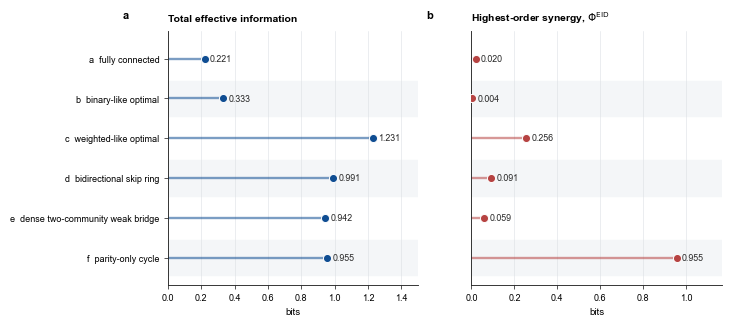

PosixPath('fig/mediano_discrete_benchmark_publication')

In [3]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["font.size"] = 7
plt.rcParams["axes.linewidth"] = 0.65
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["legend.frameon"] = False

metric_palette = {
    "ei": "#0F4D92",
    "phi": "#B64342",
    "axis": "#272727",
    "grid": "#D9DDE2",
    "band": "#F4F6F8",
}

network_labels = [f"{row['panel']}  {row['label']}" for row in publication_rows]
y_positions = np.arange(len(publication_rows))[::-1]

def _draw_metric_panel(ax, metric_key, color, title, value_format):
    values = np.array([row[metric_key] for row in publication_rows], dtype=float)
    max_value = float(values.max())
    x_pad = max_value * 0.026
    for row_index, y in enumerate(y_positions):
        if row_index % 2 == 1:
            ax.axhspan(y - 0.45, y + 0.45, color=metric_palette["band"], zorder=0)
    for y, value in zip(y_positions, values):
        ax.hlines(y, 0, value, color=color, linewidth=1.7, alpha=0.55, zorder=2)
        ax.scatter(
            value,
            y,
            s=34,
            color=color,
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )
        ax.text(
            value + x_pad,
            y,
            value_format(value),
            va="center",
            ha="left",
            fontsize=6.4,
            color=metric_palette["axis"],
        )
    ax.set_xlim(0, max_value * 1.22)
    ax.set_ylim(-0.7, len(publication_rows) - 0.3)
    ax.set_xlabel("bits", labelpad=3)
    ax.set_title(title, loc="left", fontsize=7.5, fontweight="bold", pad=7)
    ax.grid(axis="x", color=metric_palette["grid"], linewidth=0.45, alpha=0.8)
    ax.tick_params(axis="both", labelsize=6.5, width=0.55, length=2.6, color=metric_palette["axis"])
    ax.spines["left"].set_color(metric_palette["axis"])
    ax.spines["bottom"].set_color(metric_palette["axis"])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.15),
    sharey=True,
    constrained_layout=True,
)

_draw_metric_panel(
    axes[0],
    "total_ei",
    metric_palette["ei"],
    "Total effective information",
    lambda value: f"{value:.3f}",
)
_draw_metric_panel(
    axes[1],
    "phi_eid",
    metric_palette["phi"],
    r"Highest-order synergy, $\Phi^{\mathrm{EID}}$",
    lambda value: f"{value:.3f}",
)

axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(network_labels)
axes[1].tick_params(axis="y", left=False, labelleft=False)

for label, ax in zip(("a", "b"), axes):
    ax.text(
        -0.18,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        ha="left",
        va="top",
    )

quant_svg_path = publication_dir / "ei_phi_publication_lollipop.svg"
quant_pdf_path = publication_dir / "ei_phi_publication_lollipop.pdf"
quant_png_path = publication_dir / "ei_phi_publication_lollipop.png"
fig.savefig(quant_svg_path, bbox_inches="tight")
fig.savefig(quant_pdf_path, bbox_inches="tight")
fig.savefig(quant_png_path, dpi=600, bbox_inches="tight")

publication_manifest = [
    {
        "index": 0,
        "label": "Publication-style six-network mechanism overview",
        "file": str(topology_publication_path.relative_to(repo_root)),
    },
    {
        "index": 1,
        "label": "Publication-style EI and Phi^EID quantitative summary",
        "file": str(quant_svg_path.relative_to(repo_root)),
    },
    {
        "index": 2,
        "label": "Source data for the quantitative summary",
        "file": str(source_data_path.relative_to(repo_root)),
    },
]
manifest_path = publication_dir / "publication_figure_manifest.json"
manifest_path.write_text(json.dumps(publication_manifest, ensure_ascii=False, indent=2))

plt.show()
publication_dir.relative_to(repo_root)
